# How many FOVs fit in a well?

Estimate, for the plate in `PLATE_CALIBRATION_PATH`, **how many FOVs fit inside a single well** and **how far apart they are**, given:

| parameter | value | meaning |
|---|---|---|
| `FOV_MIN_DISTANCE_UM` | 700 | minimum **centre-to-centre** spacing between FOVs |
| `FOV_BORDER_UM` | 1300 | keep FOV centres at least this far from the well edge |
| `FOV_SIZE_UM` | 665 × 665 | the area one FOV actually images |

This mirrors the geometry the `FOVFinderAgent` uses: candidate centres are sampled inside a region shrunk by `border_um` on every side, and `min_distance_um` is the non-overlap spacing fed to `useq.RandomPoints`. Because `700 > 665`, the 700 µm spacing is the binding constraint and guarantees the 665 µm FOV boxes never overlap (they keep a ≈35 µm gap).

We report three numbers:
1. **Square-grid packing** — a regular grid at 700 µm pitch (the intuitive "how many fit, evenly spaced").
2. **Hexagonal packing** — the densest regular packing at the same minimum spacing (upper-ish bound).
3. **Random packing** — what the agent's `RandomPoints(allow_overlap=False)` sampler actually achieves (typically fewer than the grid).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from useq import WellPlatePlan, RandomPoints, Shape

# ---- inputs -----------------------------------------------------------------
PLATE_CALIBRATION_PATH = r".\calib_plate_96.json"  # WellPlatePlan JSON
FOV_MIN_DISTANCE_UM = 700.0  # min centre-to-centre spacing between FOVs
FOV_BORDER_UM = 1300.0  # keep FOV centres this far from the well edge
FOV_SIZE_UM = 665.0  # imaged FOV side length (square), for drawing/overlap check

plan = WellPlatePlan.from_file(PLATE_CALIBRATION_PATH)
plate = plan.plate

well_w_um = float(plate.well_size[0]) * 1000.0
well_h_um = float(plate.well_size[1]) * 1000.0
circular = bool(plate.circular_wells)

# Candidate region = well shrunk by border on every side (matches FOVFinderAgent).
inner_w = max(well_w_um - 2.0 * FOV_BORDER_UM, 0.0)
inner_h = max(well_h_um - 2.0 * FOV_BORDER_UM, 0.0)
a, b = inner_w / 2.0, inner_h / 2.0  # semi-axes of the usable region

print(
    f"plate            : {plate.name}  ({plate.rows}x{plate.columns}, "
    f"{'circular' if circular else 'rectangular'} wells)"
)
print(f"well size        : {well_w_um:.0f} x {well_h_um:.0f} um")
print(f"border           : {FOV_BORDER_UM:.0f} um")
print(
    f"usable region    : {inner_w:.0f} x {inner_h:.0f} um "
    f"({'ellipse' if circular else 'rectangle'})"
)
print(f"min FOV spacing  : {FOV_MIN_DISTANCE_UM:.0f} um (centre-to-centre)")
print(f"FOV imaged size  : {FOV_SIZE_UM:.0f} x {FOV_SIZE_UM:.0f} um")

plate            : 96-well  (8x12, circular wells)
well size        : 6400 x 6400 um
border           : 1300 um
usable region    : 3800 x 3800 um (ellipse)
min FOV spacing  : 700 um (centre-to-centre)
FOV imaged size  : 665 x 665 um


In [2]:
def _inside(x, y, a, b, circular):
    """Is (x, y) inside the usable region (ellipse if circular, else rectangle)?"""
    if a <= 0 or b <= 0:
        return np.zeros_like(x, dtype=bool)
    if circular:
        return (x / a) ** 2 + (y / b) ** 2 <= 1.0 + 1e-9
    return (np.abs(x) <= a + 1e-9) & (np.abs(y) <= b + 1e-9)


def grid_centers(a, b, pitch, circular, hexagonal=False):
    """Regular packing of centres (origin = well centre) >= `pitch` apart.

    Square grid: nearest-neighbour distance == pitch.
    Hex grid:    row spacing pitch*sqrt(3)/2, rows offset by pitch/2 ->
                 nearest-neighbour distance == pitch, densest at this spacing.
    The grid is centred on the well; a small offset search keeps the count
    representative rather than unlucky.
    """
    R = max(a, b)
    n = int(np.floor(R / pitch)) + 2
    dy = pitch * np.sqrt(3) / 2.0 if hexagonal else pitch
    best = np.empty((0, 2))
    # try a few sub-pitch shifts and keep the densest packing
    shifts = np.linspace(-pitch / 2, pitch / 2, 5)
    for ox in shifts:
        for oy in shifts:
            pts = []
            for j in range(-n, n + 1):
                y = j * dy + oy
                xoff = (pitch / 2.0 if (hexagonal and j % 2) else 0.0) + ox
                xs = np.arange(-n, n + 1) * pitch + xoff
                for x in xs:
                    if _inside(np.array(x), np.array(y), a, b, circular):
                        pts.append((x, y))
            if len(pts) > len(best):
                best = np.array(pts)
    return best


def min_nn_distance(pts):
    """Smallest centre-to-centre distance in a set of points (um)."""
    if len(pts) < 2:
        return float("nan")
    d = np.linalg.norm(pts[:, None, :] - pts[None, :, :], axis=-1)
    np.fill_diagonal(d, np.inf)
    return float(d.min())


square = grid_centers(a, b, FOV_MIN_DISTANCE_UM, circular, hexagonal=False)
hexp = grid_centers(a, b, FOV_MIN_DISTANCE_UM, circular, hexagonal=True)

print(
    f"square grid : {len(square):3d} FOVs   (nearest-neighbour spacing "
    f"{min_nn_distance(square):.0f} um)"
)
print(
    f"hex grid    : {len(hexp):3d} FOVs   (nearest-neighbour spacing "
    f"{min_nn_distance(hexp):.0f} um)"
)

square grid :  26 FOVs   (nearest-neighbour spacing 700 um)
hex grid    :  31 FOVs   (nearest-neighbour spacing 700 um)


In [3]:
# What the FOVFinderAgent actually does: useq.RandomPoints rejection-samples
# non-overlapping FOV boxes (fov size = min_distance) inside the usable region.
# It is random, so the achievable count varies with the seed -> sample many.
import warnings

shape = Shape.ELLIPSE if circular else Shape.RECTANGLE


def random_pack(seed, ask=200):
    """Place as many non-overlapping FOVs as the sampler can find for one seed."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # 'unable to generate N points' is expected
        rp = RandomPoints(
            num_points=ask,
            max_width=inner_w,
            max_height=inner_h,
            shape=shape,
            fov_width=FOV_MIN_DISTANCE_UM,
            fov_height=FOV_MIN_DISTANCE_UM,
            allow_overlap=False,
            random_seed=int(seed),
        )
        return np.array([(p.x, p.y) for p in rp])


samples = [random_pack(s) for s in range(20)]
counts = np.array([len(s) for s in samples])
best_random = samples[int(np.argmax(counts))]

print(
    f"random packing over 20 seeds: min={counts.min()}  "
    f"median={int(np.median(counts))}  max={counts.max()} FOVs"
)
print(
    f"  (the agent's actual yield per well, before cell-count/feature "
    f"filtering, sits in this range)"
)
print(
    f"best random sample: {len(best_random)} FOVs, "
    f"min spacing {min_nn_distance(best_random):.0f} um"
)

random packing over 20 seeds: min=13  median=16  max=19 FOVs
  (the agent's actual yield per well, before cell-count/feature filtering, sits in this range)
best random sample: 19 FOVs, min spacing 706 um


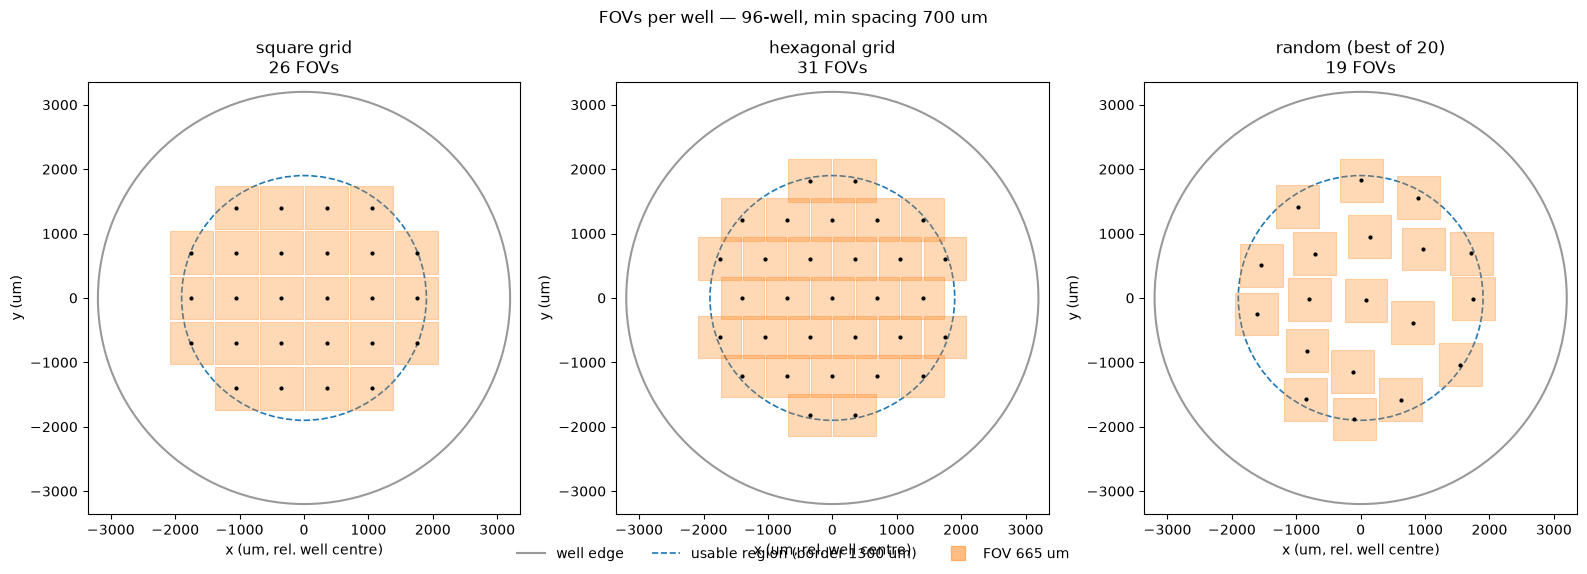

In [4]:
from matplotlib.patches import Circle, Rectangle

well_a, well_b = well_w_um / 2.0, well_h_um / 2.0
panels = [
    ("square grid", square),
    ("hexagonal grid", hexp),
    ("random (best of 20)", best_random),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, (title, pts) in zip(axes, panels):
    # well outline + usable (border-shrunk) region
    if circular:
        ax.add_patch(Circle((0, 0), well_a, fill=False, ec="0.6", lw=1.5))
        ax.add_patch(Circle((0, 0), a, fill=False, ec="tab:blue", ls="--", lw=1.2))
    else:
        ax.add_patch(
            Rectangle(
                (-well_a, -well_b), 2 * well_a, 2 * well_b, fill=False, ec="0.6", lw=1.5
            )
        )
        ax.add_patch(
            Rectangle(
                (-a, -b), 2 * a, 2 * b, fill=False, ec="tab:blue", ls="--", lw=1.2
            )
        )
    # imaged FOV boxes (actual 665 um) + centres
    for x, y in pts:
        ax.add_patch(
            Rectangle(
                (x - FOV_SIZE_UM / 2, y - FOV_SIZE_UM / 2),
                FOV_SIZE_UM,
                FOV_SIZE_UM,
                fill=True,
                fc="tab:orange",
                alpha=0.30,
                ec="tab:orange",
                lw=0.8,
            )
        )
    if len(pts):
        ax.plot(pts[:, 0], pts[:, 1], "k.", ms=4)
    ax.set_title(f"{title}\n{len(pts)} FOVs")
    ax.set_xlabel("x (um, rel. well centre)")
    ax.set_ylabel("y (um)")
    ax.set_aspect("equal")
    lim = well_a * 1.05
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

# legend (built once)
from matplotlib.lines import Line2D

handles = [
    Line2D([0], [0], color="0.6", lw=1.5, label="well edge"),
    Line2D(
        [0],
        [0],
        color="tab:blue",
        ls="--",
        lw=1.2,
        label=f"usable region (border {FOV_BORDER_UM:.0f} um)",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="tab:orange",
        lw=0,
        alpha=0.5,
        markersize=10,
        label=f"FOV {FOV_SIZE_UM:.0f} um",
    ),
]
fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False)
fig.suptitle(
    f"FOVs per well — {plate.name}, min spacing {FOV_MIN_DISTANCE_UM:.0f} um",
    y=1.02,
)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [5]:
print("=" * 60)
print(
    f"FOVs per well  ({plate.name}, well {well_w_um:.0f} um, "
    f"border {FOV_BORDER_UM:.0f} um, spacing >= {FOV_MIN_DISTANCE_UM:.0f} um)"
)
print("=" * 60)
print(
    f"  square-grid packing : {len(square):3d} FOVs  (evenly spaced, "
    f"{min_nn_distance(square):.0f} um apart)"
)
print(f"  hex packing (max)   : {len(hexp):3d} FOVs  (densest at this spacing)")
print(
    f"  random (agent path) : {counts.min()}-{counts.max()} FOVs  "
    f"(median {int(np.median(counts))})"
)
print()
print("Notes:")
print(
    f"  - 700 um spacing > 665 um FOV, so FOV boxes never overlap "
    f"(~{FOV_MIN_DISTANCE_UM - FOV_SIZE_UM:.0f} um gap)."
)
print(
    "  - The FOVFinderAgent samples FOVs randomly, so plan for the " "'random' range,"
)
print(
    "    and set n_candidates_per_well below that to avoid the "
    "'unable to generate' warning."
)

FOVs per well  (96-well, well 6400 um, border 1300 um, spacing >= 700 um)
  square-grid packing :  26 FOVs  (evenly spaced, 700 um apart)
  hex packing (max)   :  31 FOVs  (densest at this spacing)
  random (agent path) : 13-19 FOVs  (median 16)

Notes:
  - 700 um spacing > 665 um FOV, so FOV boxes never overlap (~35 um gap).
  - The FOVFinderAgent samples FOVs randomly, so plan for the 'random' range,
    and set n_candidates_per_well below that to avoid the 'unable to generate' warning.
